In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/akashdeepkuila/big-mart-sales/Test-Set.csv
/kaggle/input/datasets/akashdeepkuila/big-mart-sales/Train-Set.csv


In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder


import tensorflow as tf 
import keras
import keras_tuner as kt
from keras.layers import Dense
from keras.layers import Dropout
from keras.layers import BatchNormalization
from keras.layers import LeakyReLU
from keras.models import Sequential 
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam

In [3]:
test  = pd.read_csv('/kaggle/input/datasets/akashdeepkuila/big-mart-sales/Test-Set.csv')
train = pd.read_csv('/kaggle/input/datasets/akashdeepkuila/big-mart-sales/Train-Set.csv')

In [4]:
test.head()

,ProductID,Weight,FatContent,ProductVisibility,ProductType,MRP,OutletID,EstablishmentYear,OutletSize,LocationType,OutletType
0,FDW58,20.750,Low Fat,0.007565,Snack Foods,107.8622,OUT049,1999,Medium,Tier 1,Supermarket Type1
1,FDW14,8.300,reg,0.038428,Dairy,87.3198,OUT017,2007,NaN,Tier 2,Supermarket Type1
2,NCN55,14.600,Low Fat,0.099575,Others,241.7538,OUT010,1998,NaN,Tier 3,Grocery Store
3,FDQ58,7.315,Low Fat,0.015388,Snack Foods,155.0340,OUT017,2007,NaN,Tier 2,Supermarket Type1
4,FDY38,NaN,Regular,0.118599,Dairy,234.2300,OUT027,1985,Medium,Tier 3,Supermarket Type3


In [5]:
train.head()

,ProductID,Weight,FatContent,ProductVisibility,ProductType,MRP,OutletID,EstablishmentYear,OutletSize,LocationType,OutletType,OutletSales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


# Preprocessing Train data 

In [6]:
train.head()

,ProductID,Weight,FatContent,ProductVisibility,ProductType,MRP,OutletID,EstablishmentYear,OutletSize,LocationType,OutletType,OutletSales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [7]:
train.shape

(8523, 12)

In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ProductID          8523 non-null   object 
 1   Weight             7060 non-null   float64
 2   FatContent         8523 non-null   object 
 3   ProductVisibility  8523 non-null   float64
 4   ProductType        8523 non-null   object 
 5   MRP                8523 non-null   float64
 6   OutletID           8523 non-null   object 
 7   EstablishmentYear  8523 non-null   int64  
 8   OutletSize         6113 non-null   object 
 9   LocationType       8523 non-null   object 
 10  OutletType         8523 non-null   object 
 11  OutletSales        8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [9]:
train.isna().sum().sum()

np.int64(3873)

In [10]:
train.isna().sum()

ProductID               0
Weight               1463
FatContent              0
ProductVisibility       0
ProductType             0
MRP                     0
OutletID                0
EstablishmentYear       0
OutletSize           2410
LocationType            0
OutletType              0
OutletSales             0
dtype: int64

## Distribution in columns 

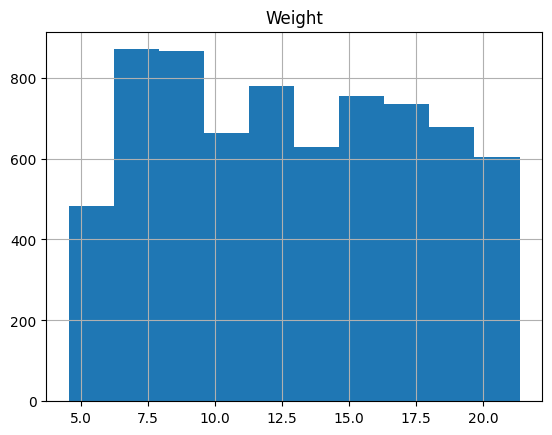

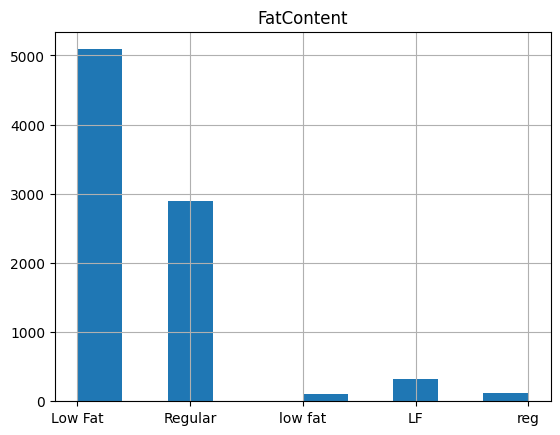

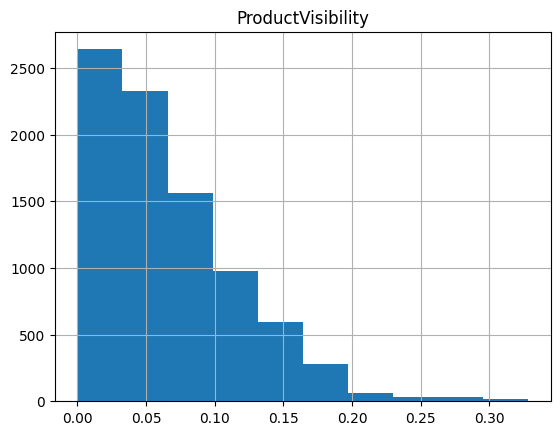

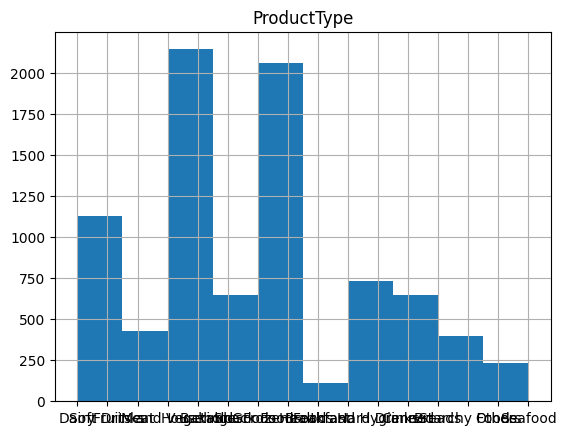

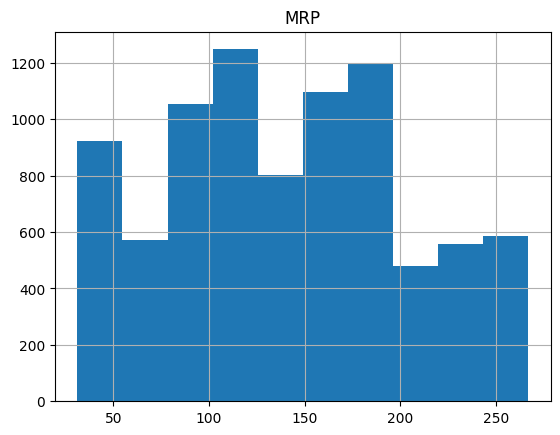

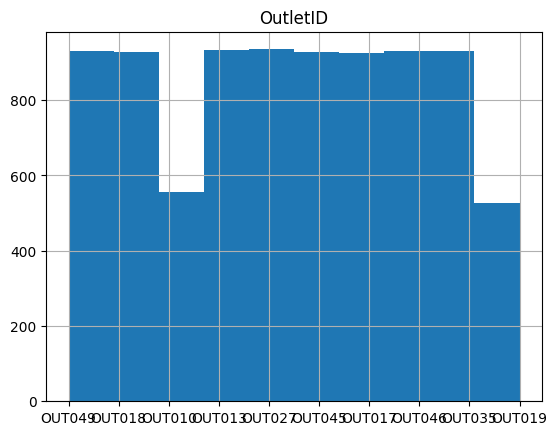

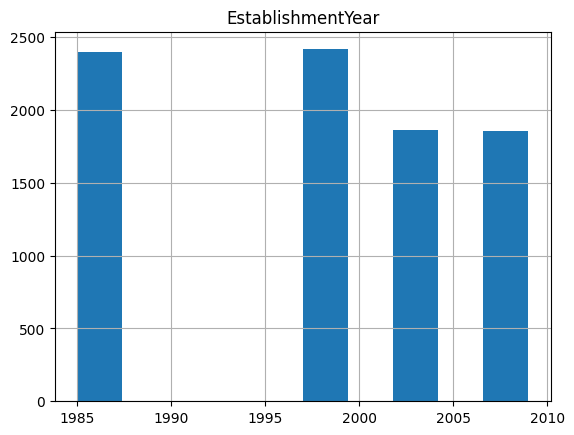

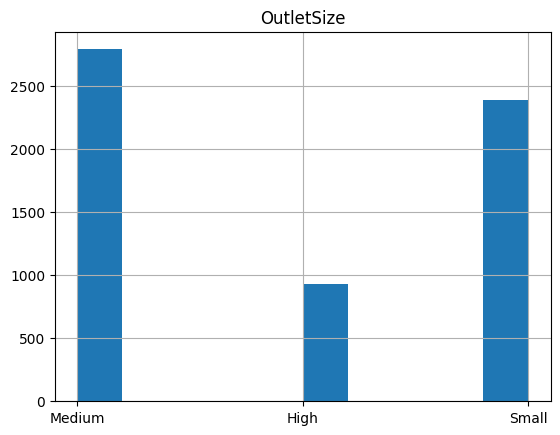

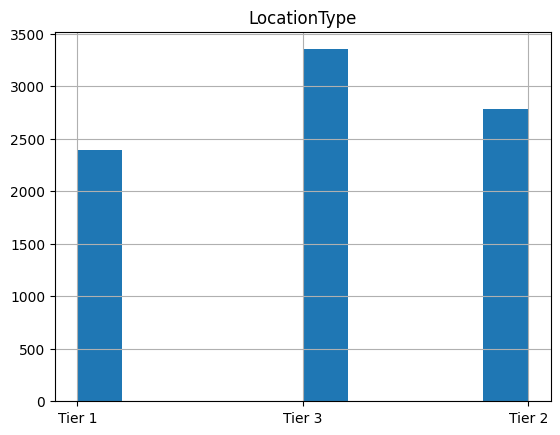

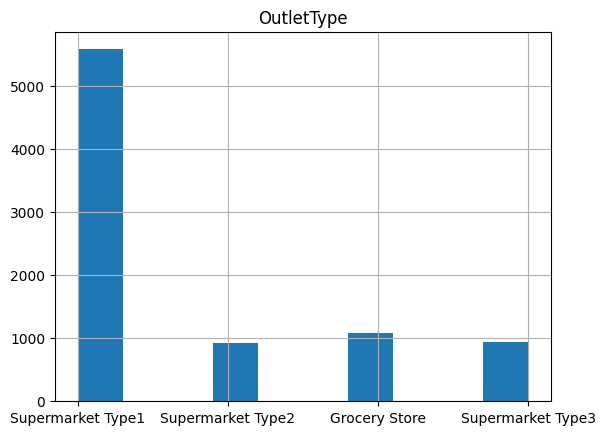

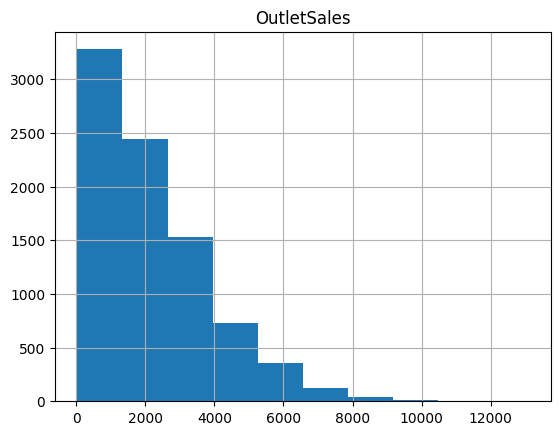

In [11]:

# skip product id
for col in train.columns[1:]:
    plt.title(col)
    train[col].hist()
    plt.show()

In [12]:
train.isna().sum()

ProductID               0
Weight               1463
FatContent              0
ProductVisibility       0
ProductType             0
MRP                     0
OutletID                0
EstablishmentYear       0
OutletSize           2410
LocationType            0
OutletType              0
OutletSales             0
dtype: int64

In [13]:
nan_col = ['Weight','OutletSize']
for col in nan_col:
    print(train[col].value_counts())
    print()

Weight
12.150    86
17.600    82
13.650    77
11.800    76
15.100    68
          ..
8.920      2
6.520      1
9.420      1
7.685      1
5.400      1
Name: count, Length: 415, dtype: int64

OutletSize
Medium    2793
Small     2388
High       932
Name: count, dtype: int64



In [14]:
train['Weight'] = train['Weight'].fillna(train['Weight'].median())

In [15]:
train['OutletSize'].value_counts()

OutletSize
Medium    2793
Small     2388
High       932
Name: count, dtype: int64

In [16]:
train[train['OutletSize'].isna()]

,ProductID,Weight,FatContent,ProductVisibility,ProductType,MRP,OutletID,EstablishmentYear,OutletSize,LocationType,OutletType,OutletSales
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
8,FDH17,16.200,Regular,0.016687,Frozen Foods,96.9726,OUT045,2002,NaN,Tier 2,Supermarket Type1,1076.5986
9,FDU28,19.200,Regular,0.094450,Frozen Foods,187.8214,OUT017,2007,NaN,Tier 2,Supermarket Type1,4710.5350
25,NCD06,13.000,Low Fat,0.099887,Household,45.9060,OUT017,2007,NaN,Tier 2,Supermarket Type1,838.9080
28,FDE51,5.925,Regular,0.161467,Dairy,45.5086,OUT010,1998,NaN,Tier 3,Grocery Store,178.4344
...,...,...,...,...,...,...,...,...,...,...,...,...
8502,NCH43,8.420,Low Fat,0.070712,Household,216.4192,OUT045,2002,NaN,Tier 2,Supermarket Type1,3020.0688
8508,FDW31,11.350,Regular,0.043246,Fruits and Vegetables,199.4742,OUT045,2002,NaN,Tier 2,Supermarket Type1,2587.9646
8509,FDG45,8.100,Low Fat,0.214306,Fruits and Vegetables,213.9902,OUT010,1998,NaN,Tier 3,Grocery Store,424.7804
8514,FDA01,15.000,Regular,0.054489,Canned,57.5904,OUT045,2002,NaN,Tier 2,Supermarket Type1,468.7232


In [17]:
train.isna().sum()

ProductID               0
Weight                  0
FatContent              0
ProductVisibility       0
ProductType             0
MRP                     0
OutletID                0
EstablishmentYear       0
OutletSize           2410
LocationType            0
OutletType              0
OutletSales             0
dtype: int64

In [18]:
for location in train['LocationType'].unique():
    print(f'LocationType: {location}\n')

    for outlet in train['OutletType'].unique():
        print(f'OutletType: {outlet}')

        subset = train[
            (train['LocationType'] == location) &
            (train['OutletType'] == outlet)
        ]

        # NaN count for each column
        nan_counts = subset.isna().sum()

        # Keep only columns having NaN values
        nan_columns = nan_counts[nan_counts > 0]
        if nan_columns is not None:
            print("Columns with NaN:")
            print(nan_columns)
            print()

    print("*" * 40)

LocationType: Tier 1

OutletType: Supermarket Type1
Columns with NaN:
Series([], dtype: int64)

OutletType: Supermarket Type2
Columns with NaN:
Series([], dtype: int64)

OutletType: Grocery Store
Columns with NaN:
Series([], dtype: int64)

OutletType: Supermarket Type3
Columns with NaN:
Series([], dtype: int64)

****************************************
LocationType: Tier 3

OutletType: Supermarket Type1
Columns with NaN:
Series([], dtype: int64)

OutletType: Supermarket Type2
Columns with NaN:
Series([], dtype: int64)

OutletType: Grocery Store
Columns with NaN:
OutletSize    555
dtype: int64

OutletType: Supermarket Type3
Columns with NaN:
Series([], dtype: int64)

****************************************
LocationType: Tier 2

OutletType: Supermarket Type1
Columns with NaN:
OutletSize    1855
dtype: int64

OutletType: Supermarket Type2
Columns with NaN:
Series([], dtype: int64)

OutletType: Grocery Store
Columns with NaN:
Series([], dtype: int64)

OutletType: Supermarket Type3
Columns

In [19]:
train.groupby("OutletID")["OutletSize"].unique()

OutletID
OUT010       [nan]
OUT013      [High]
OUT017       [nan]
OUT018    [Medium]
OUT019     [Small]
OUT027    [Medium]
OUT035     [Small]
OUT045       [nan]
OUT046     [Small]
OUT049    [Medium]
Name: OutletSize, dtype: object

In [20]:
# outlets haveing missing outlet size
train.loc[train["OutletSize"].isna(),
          ["OutletID","OutletType","LocationType"]].drop_duplicates()

,OutletID,OutletType,LocationType
3,OUT010,Grocery Store,Tier 3
8,OUT045,Supermarket Type1,Tier 2
9,OUT017,Supermarket Type1,Tier 2


In [21]:
train[
    (train.LocationType=="Tier 3") &
    (train.OutletType=="Grocery Store")
]["OutletSize"].value_counts(dropna=False)

# hence tier 3 grocery soter outlet size will be small

OutletSize
NaN    555
Name: count, dtype: int64

In [22]:
train[
    (train.LocationType=="Tier 2") &
    (train.OutletType=="Supermarket Type1")
]["OutletSize"].value_counts()

OutletSize
Small    930
Name: count, dtype: int64

In [23]:
train.loc[
    (train["LocationType"] == "Tier 3") &
    (train["OutletType"] == "Grocery Store"),
    "OutletID"
].value_counts()

OutletID
OUT010    555
Name: count, dtype: int64

In [24]:
# filling the nan values

In [25]:
# Tier3 Grocery Store
mask = (
    (train["LocationType"]=="Tier 3") &
    (train["OutletType"]=="Grocery Store")
)

train.loc[mask, "OutletSize"] = "unknown"

In [26]:
# Tier2 Supermarket Type1
mask = (
    (train["LocationType"]=="Tier 2") &
    (train["OutletType"]=="Supermarket Type1")
)

train.loc[mask, "OutletSize"] = "small"

In [27]:
train.isna().sum()

ProductID            0
Weight               0
FatContent           0
ProductVisibility    0
ProductType          0
MRP                  0
OutletID             0
EstablishmentYear    0
OutletSize           0
LocationType         0
OutletType           0
OutletSales          0
dtype: int64

In [28]:
train.duplicated().sum()

np.int64(0)

### Searching for zero values

In [29]:
j = 0
for i in train.columns:
    if (train[i].dtype == 'int64' and (train[i]==0).sum()!=0):
        print(j+1,'. ',i ,train[i].dtype ,(train[i]==0).sum())
        j=j+1 
print('\nTotal Features: ', j)


Total Features:  0


In [30]:
j = 0
for i in train.columns:
    if (train[i].dtype == 'float64' and (train[i]==0).sum()!=0):
        print(j+1,'. ',i ,train[i].dtype ,(train[i]==0).sum())
        j=j+1 
print('\nTotal Features: ', j)

1 .  ProductVisibility float64 526

Total Features:  1


In [31]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ProductID          8523 non-null   object 
 1   Weight             8523 non-null   float64
 2   FatContent         8523 non-null   object 
 3   ProductVisibility  8523 non-null   float64
 4   ProductType        8523 non-null   object 
 5   MRP                8523 non-null   float64
 6   OutletID           8523 non-null   object 
 7   EstablishmentYear  8523 non-null   int64  
 8   OutletSize         8523 non-null   object 
 9   LocationType       8523 non-null   object 
 10  OutletType         8523 non-null   object 
 11  OutletSales        8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [32]:
train.drop(columns=['ProductID','OutletID'],inplace=True)
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Weight             8523 non-null   float64
 1   FatContent         8523 non-null   object 
 2   ProductVisibility  8523 non-null   float64
 3   ProductType        8523 non-null   object 
 4   MRP                8523 non-null   float64
 5   EstablishmentYear  8523 non-null   int64  
 6   OutletSize         8523 non-null   object 
 7   LocationType       8523 non-null   object 
 8   OutletType         8523 non-null   object 
 9   OutletSales        8523 non-null   float64
dtypes: float64(4), int64(1), object(5)
memory usage: 666.0+ KB


### Encoding Object columns

In [33]:
j = 0
for i in train.columns:
    if (train[i].dtype == 'object'):
        print(j+1,'. ',i ,train[i].dtype)
        j=j+1 
print('\nTotal Features: ', j)

1 .  FatContent object
2 .  ProductType object
3 .  OutletSize object
4 .  LocationType object
5 .  OutletType object

Total Features:  5


In [34]:
categorical_cols = [
    "FatContent",
    "ProductType",
    "OutletSize",
    "LocationType",
    "OutletType"
]

# Preprocessing Test data 

In [35]:
test.head()

,ProductID,Weight,FatContent,ProductVisibility,ProductType,MRP,OutletID,EstablishmentYear,OutletSize,LocationType,OutletType
0,FDW58,20.750,Low Fat,0.007565,Snack Foods,107.8622,OUT049,1999,Medium,Tier 1,Supermarket Type1
1,FDW14,8.300,reg,0.038428,Dairy,87.3198,OUT017,2007,NaN,Tier 2,Supermarket Type1
2,NCN55,14.600,Low Fat,0.099575,Others,241.7538,OUT010,1998,NaN,Tier 3,Grocery Store
3,FDQ58,7.315,Low Fat,0.015388,Snack Foods,155.0340,OUT017,2007,NaN,Tier 2,Supermarket Type1
4,FDY38,NaN,Regular,0.118599,Dairy,234.2300,OUT027,1985,Medium,Tier 3,Supermarket Type3


In [36]:
test.shape

(5681, 11)

In [37]:
test.isna().sum()

ProductID               0
Weight                976
FatContent              0
ProductVisibility       0
ProductType             0
MRP                     0
OutletID                0
EstablishmentYear       0
OutletSize           1606
LocationType            0
OutletType              0
dtype: int64

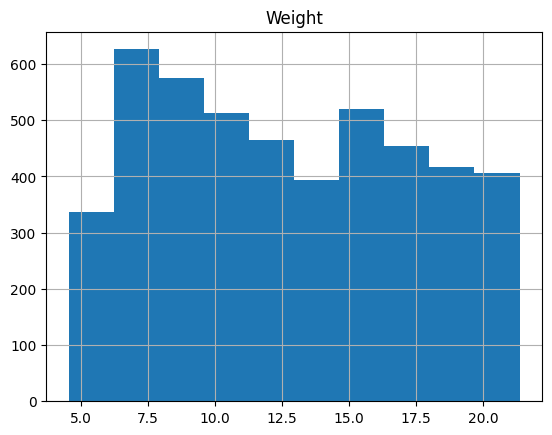

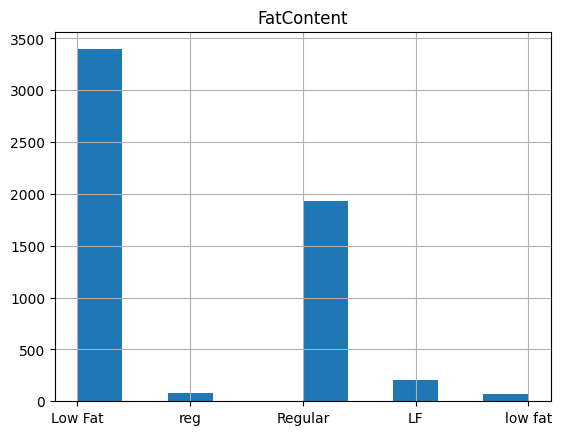

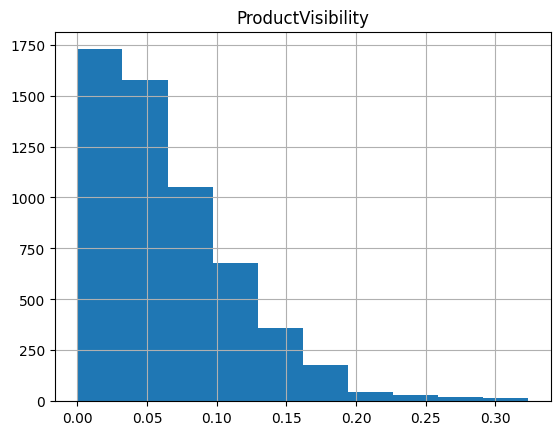

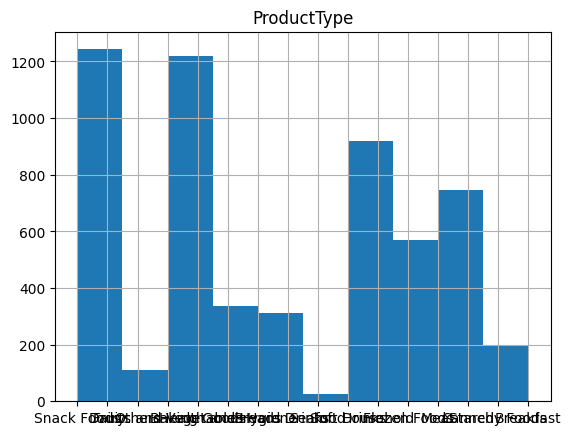

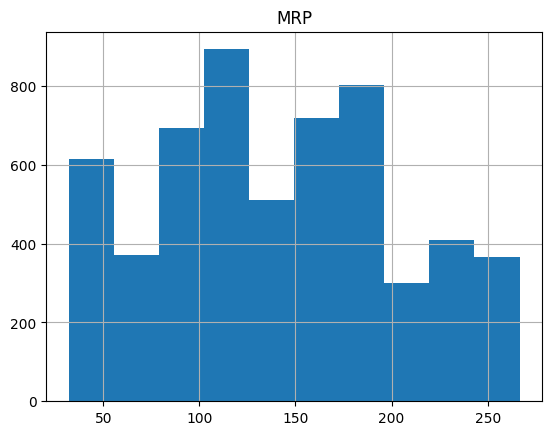

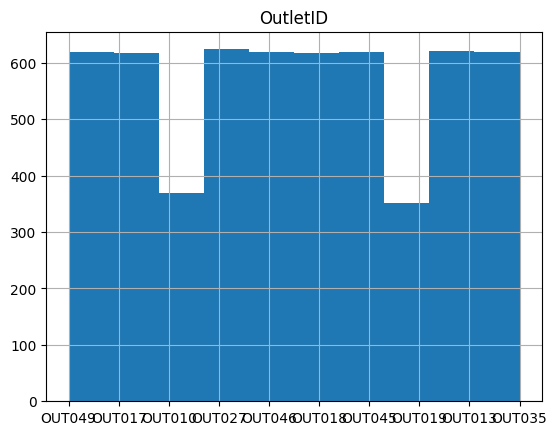

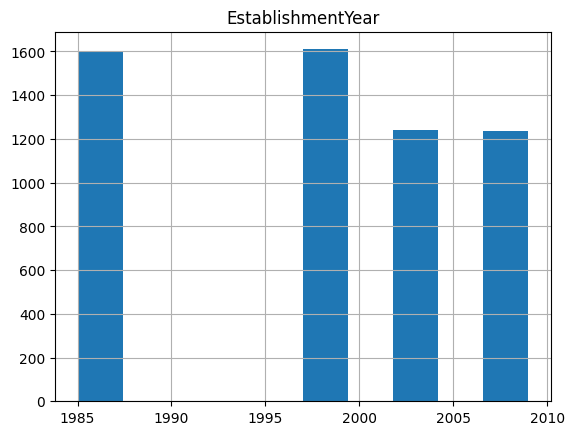

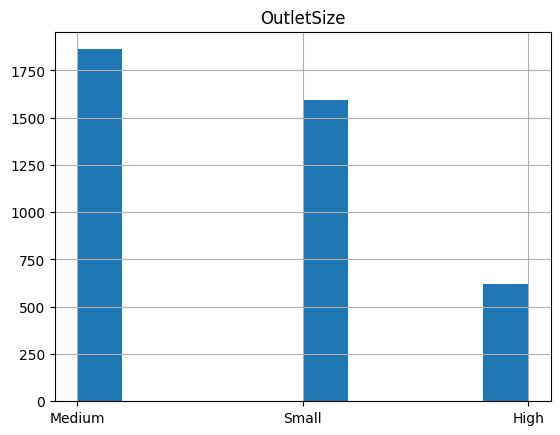

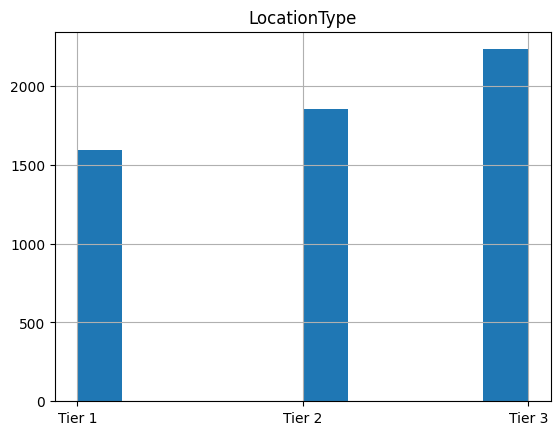

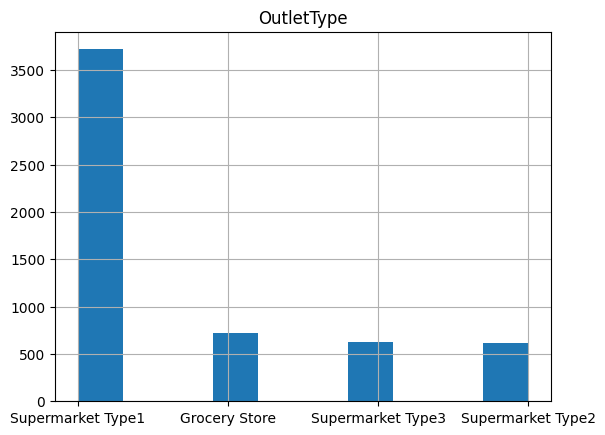

In [38]:

# skip product id
for col in test.columns[1:]:
    plt.title(col)
    test[col].hist()
    plt.show()

In [39]:
# handling missing value in weight
test['Weight'] = test['Weight'].fillna(test['Weight'].median())

In [40]:
test.isna().sum()

ProductID               0
Weight                  0
FatContent              0
ProductVisibility       0
ProductType             0
MRP                     0
OutletID                0
EstablishmentYear       0
OutletSize           1606
LocationType            0
OutletType              0
dtype: int64

In [41]:
# outlets haveing missing outlet size
test.loc[test["OutletSize"].isna(),
          ["OutletID","OutletType","LocationType"]].drop_duplicates()

,OutletID,OutletType,LocationType
1,OUT017,Supermarket Type1,Tier 2
2,OUT010,Grocery Store,Tier 3
8,OUT045,Supermarket Type1,Tier 2


In [42]:
test[
    (test.LocationType=="Tier 2") &
    (test.OutletType=="Supermarket Type1")
]["OutletSize"].value_counts()

OutletSize
Small    620
Name: count, dtype: int64

In [43]:
test[
    (test.LocationType=="Tier 3") &
    (test.OutletType=="Grocery Store")
]["OutletSize"].value_counts(dropna=False)


OutletSize
NaN    370
Name: count, dtype: int64

In [44]:
# filling grocery store
mask = (
    (test["LocationType"]=="Tier 3") &
    (test["OutletType"]=="Grocery Store")
)

test.loc[mask, "OutletSize"] = "unknown"

In [45]:
# filling Tier2 Supermarket Type1
mask = (
    (test["LocationType"]=="Tier 2") &
    (test["OutletType"]=="Supermarket Type1")
)

test.loc[mask, "OutletSize"] = "small"

In [46]:
test.isna().sum()

ProductID            0
Weight               0
FatContent           0
ProductVisibility    0
ProductType          0
MRP                  0
OutletID             0
EstablishmentYear    0
OutletSize           0
LocationType         0
OutletType           0
dtype: int64

In [47]:
test.duplicated().sum()

np.int64(0)

### Searching for zero values 

In [48]:
j=0
for i in test.columns:
    if (test[i].dtype == 'int64' and (test[i]==0).sum()!=0):
        print(j+1,'. ',i ,test[i].dtype ,(test[i]==0).sum())
        j=j+1 
print('\nTotal Features: ', j)


Total Features:  0


In [49]:
j=0
for i in test.columns:
    if (test[i].dtype == 'float64' and (test[i]==0).sum()!=0):
        print(j+1,'. ',i ,test[i].dtype ,(test[i]==0).sum())
        j=j+1 
print('\nTotal Features: ', j)

1 .  ProductVisibility float64 353

Total Features:  1


In [50]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5681 entries, 0 to 5680
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ProductID          5681 non-null   object 
 1   Weight             5681 non-null   float64
 2   FatContent         5681 non-null   object 
 3   ProductVisibility  5681 non-null   float64
 4   ProductType        5681 non-null   object 
 5   MRP                5681 non-null   float64
 6   OutletID           5681 non-null   object 
 7   EstablishmentYear  5681 non-null   int64  
 8   OutletSize         5681 non-null   object 
 9   LocationType       5681 non-null   object 
 10  OutletType         5681 non-null   object 
dtypes: float64(3), int64(1), object(7)
memory usage: 488.3+ KB


In [51]:
test.drop(columns=['ProductID','OutletID'],inplace=True)
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5681 entries, 0 to 5680
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Weight             5681 non-null   float64
 1   FatContent         5681 non-null   object 
 2   ProductVisibility  5681 non-null   float64
 3   ProductType        5681 non-null   object 
 4   MRP                5681 non-null   float64
 5   EstablishmentYear  5681 non-null   int64  
 6   OutletSize         5681 non-null   object 
 7   LocationType       5681 non-null   object 
 8   OutletType         5681 non-null   object 
dtypes: float64(3), int64(1), object(5)
memory usage: 399.6+ KB


In [52]:
j = 0
for i in test.columns:
    if (test[i].dtype == 'object'):
        print(j+1,'. ',i ,test[i].dtype)
        j=j+1 
print('\nTotal Features: ', j)

1 .  FatContent object
2 .  ProductType object
3 .  OutletSize object
4 .  LocationType object
5 .  OutletType object

Total Features:  5


In [53]:
categorical_cols = [
    "FatContent",
    "ProductType",
    "OutletSize",
    "LocationType",
    "OutletType"
]

# Encoding bot test and train data set

In [54]:
# Fit the encoder on the training data
encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore"
)

encoder.fit(train[categorical_cols])

OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [55]:
# Transform both datasets
train_encoded = encoder.transform(train[categorical_cols])
test_encoded = encoder.transform(test[categorical_cols])

In [56]:
# Convert back to DataFrames
encoded_columns = encoder.get_feature_names_out(categorical_cols)

train_encoded = pd.DataFrame(
    train_encoded,
    columns=encoded_columns,
    index=train.index
)

test_encoded = pd.DataFrame(
    test_encoded,
    columns=encoded_columns,
    index=test.index
)

In [57]:
# Drop original columns and join encoded columns
train = train.drop(columns=categorical_cols)
test = test.drop(columns=categorical_cols)

train = pd.concat([train, train_encoded], axis=1)
test = pd.concat([test, test_encoded], axis=1)

### Scaling

In [58]:
train.columns

Index(['Weight', 'ProductVisibility', 'MRP', 'EstablishmentYear',
       'OutletSales', 'FatContent_LF', 'FatContent_Low Fat',
       'FatContent_Regular', 'FatContent_low fat', 'FatContent_reg',
       'ProductType_Baking Goods', 'ProductType_Breads',
       'ProductType_Breakfast', 'ProductType_Canned', 'ProductType_Dairy',
       'ProductType_Frozen Foods', 'ProductType_Fruits and Vegetables',
       'ProductType_Hard Drinks', 'ProductType_Health and Hygiene',
       'ProductType_Household', 'ProductType_Meat', 'ProductType_Others',
       'ProductType_Seafood', 'ProductType_Snack Foods',
       'ProductType_Soft Drinks', 'ProductType_Starchy Foods',
       'OutletSize_High', 'OutletSize_Medium', 'OutletSize_Small',
       'OutletSize_small', 'OutletSize_unknown', 'LocationType_Tier 1',
       'LocationType_Tier 2', 'LocationType_Tier 3',
       'OutletType_Grocery Store', 'OutletType_Supermarket Type1',
       'OutletType_Supermarket Type2', 'OutletType_Supermarket Type3'],
      d

In [59]:
numerical_cols = [
    'Weight','ProductVisibility','MRP','EstablishmentYear'
]

In [60]:
scaler = StandardScaler()

train[numerical_cols] = scaler.fit_transform(train[numerical_cols])
test[numerical_cols] = scaler.fit_transform(test[numerical_cols])

In [61]:
train.head()

,Weight,ProductVisibility,MRP,EstablishmentYear,OutletSales,FatContent_LF,FatContent_Low Fat,FatContent_Regular,FatContent_low fat,FatContent_reg,...,OutletSize_Small,OutletSize_small,OutletSize_unknown,LocationType_Tier 1,LocationType_Tier 2,LocationType_Tier 3,OutletType_Grocery Store,OutletType_Supermarket Type1,OutletType_Supermarket Type2,OutletType_Supermarket Type3
0,-0.831187,-0.970732,1.747454,0.139541,3735.1380,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,-1.630810,-0.908111,-1.489023,1.334103,443.4228,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,1.108727,-0.956917,0.010040,0.139541,2097.2700,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1.510904,-1.281758,0.660050,0.020085,732.3800,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
4,-0.918719,-1.281758,-1.399220,-1.293934,994.7052,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [62]:
test.head()

,Weight,ProductVisibility,MRP,EstablishmentYear,FatContent_LF,FatContent_Low Fat,FatContent_Regular,FatContent_low fat,FatContent_reg,ProductType_Baking Goods,...,OutletSize_Small,OutletSize_small,OutletSize_unknown,LocationType_Tier 1,LocationType_Tier 2,LocationType_Tier 3,OutletType_Grocery Store,OutletType_Supermarket Type1,OutletType_Supermarket Type2,OutletType_Supermarket Type3
0,1.905090,-1.134077,-0.536555,0.139891,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,-1.027457,-0.531850,-0.868937,1.095512,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,0.456482,0.661316,1.629848,0.020438,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
3,-1.259469,-0.981416,0.226697,1.095512,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,-0.038164,1.032540,1.508110,-1.532446,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


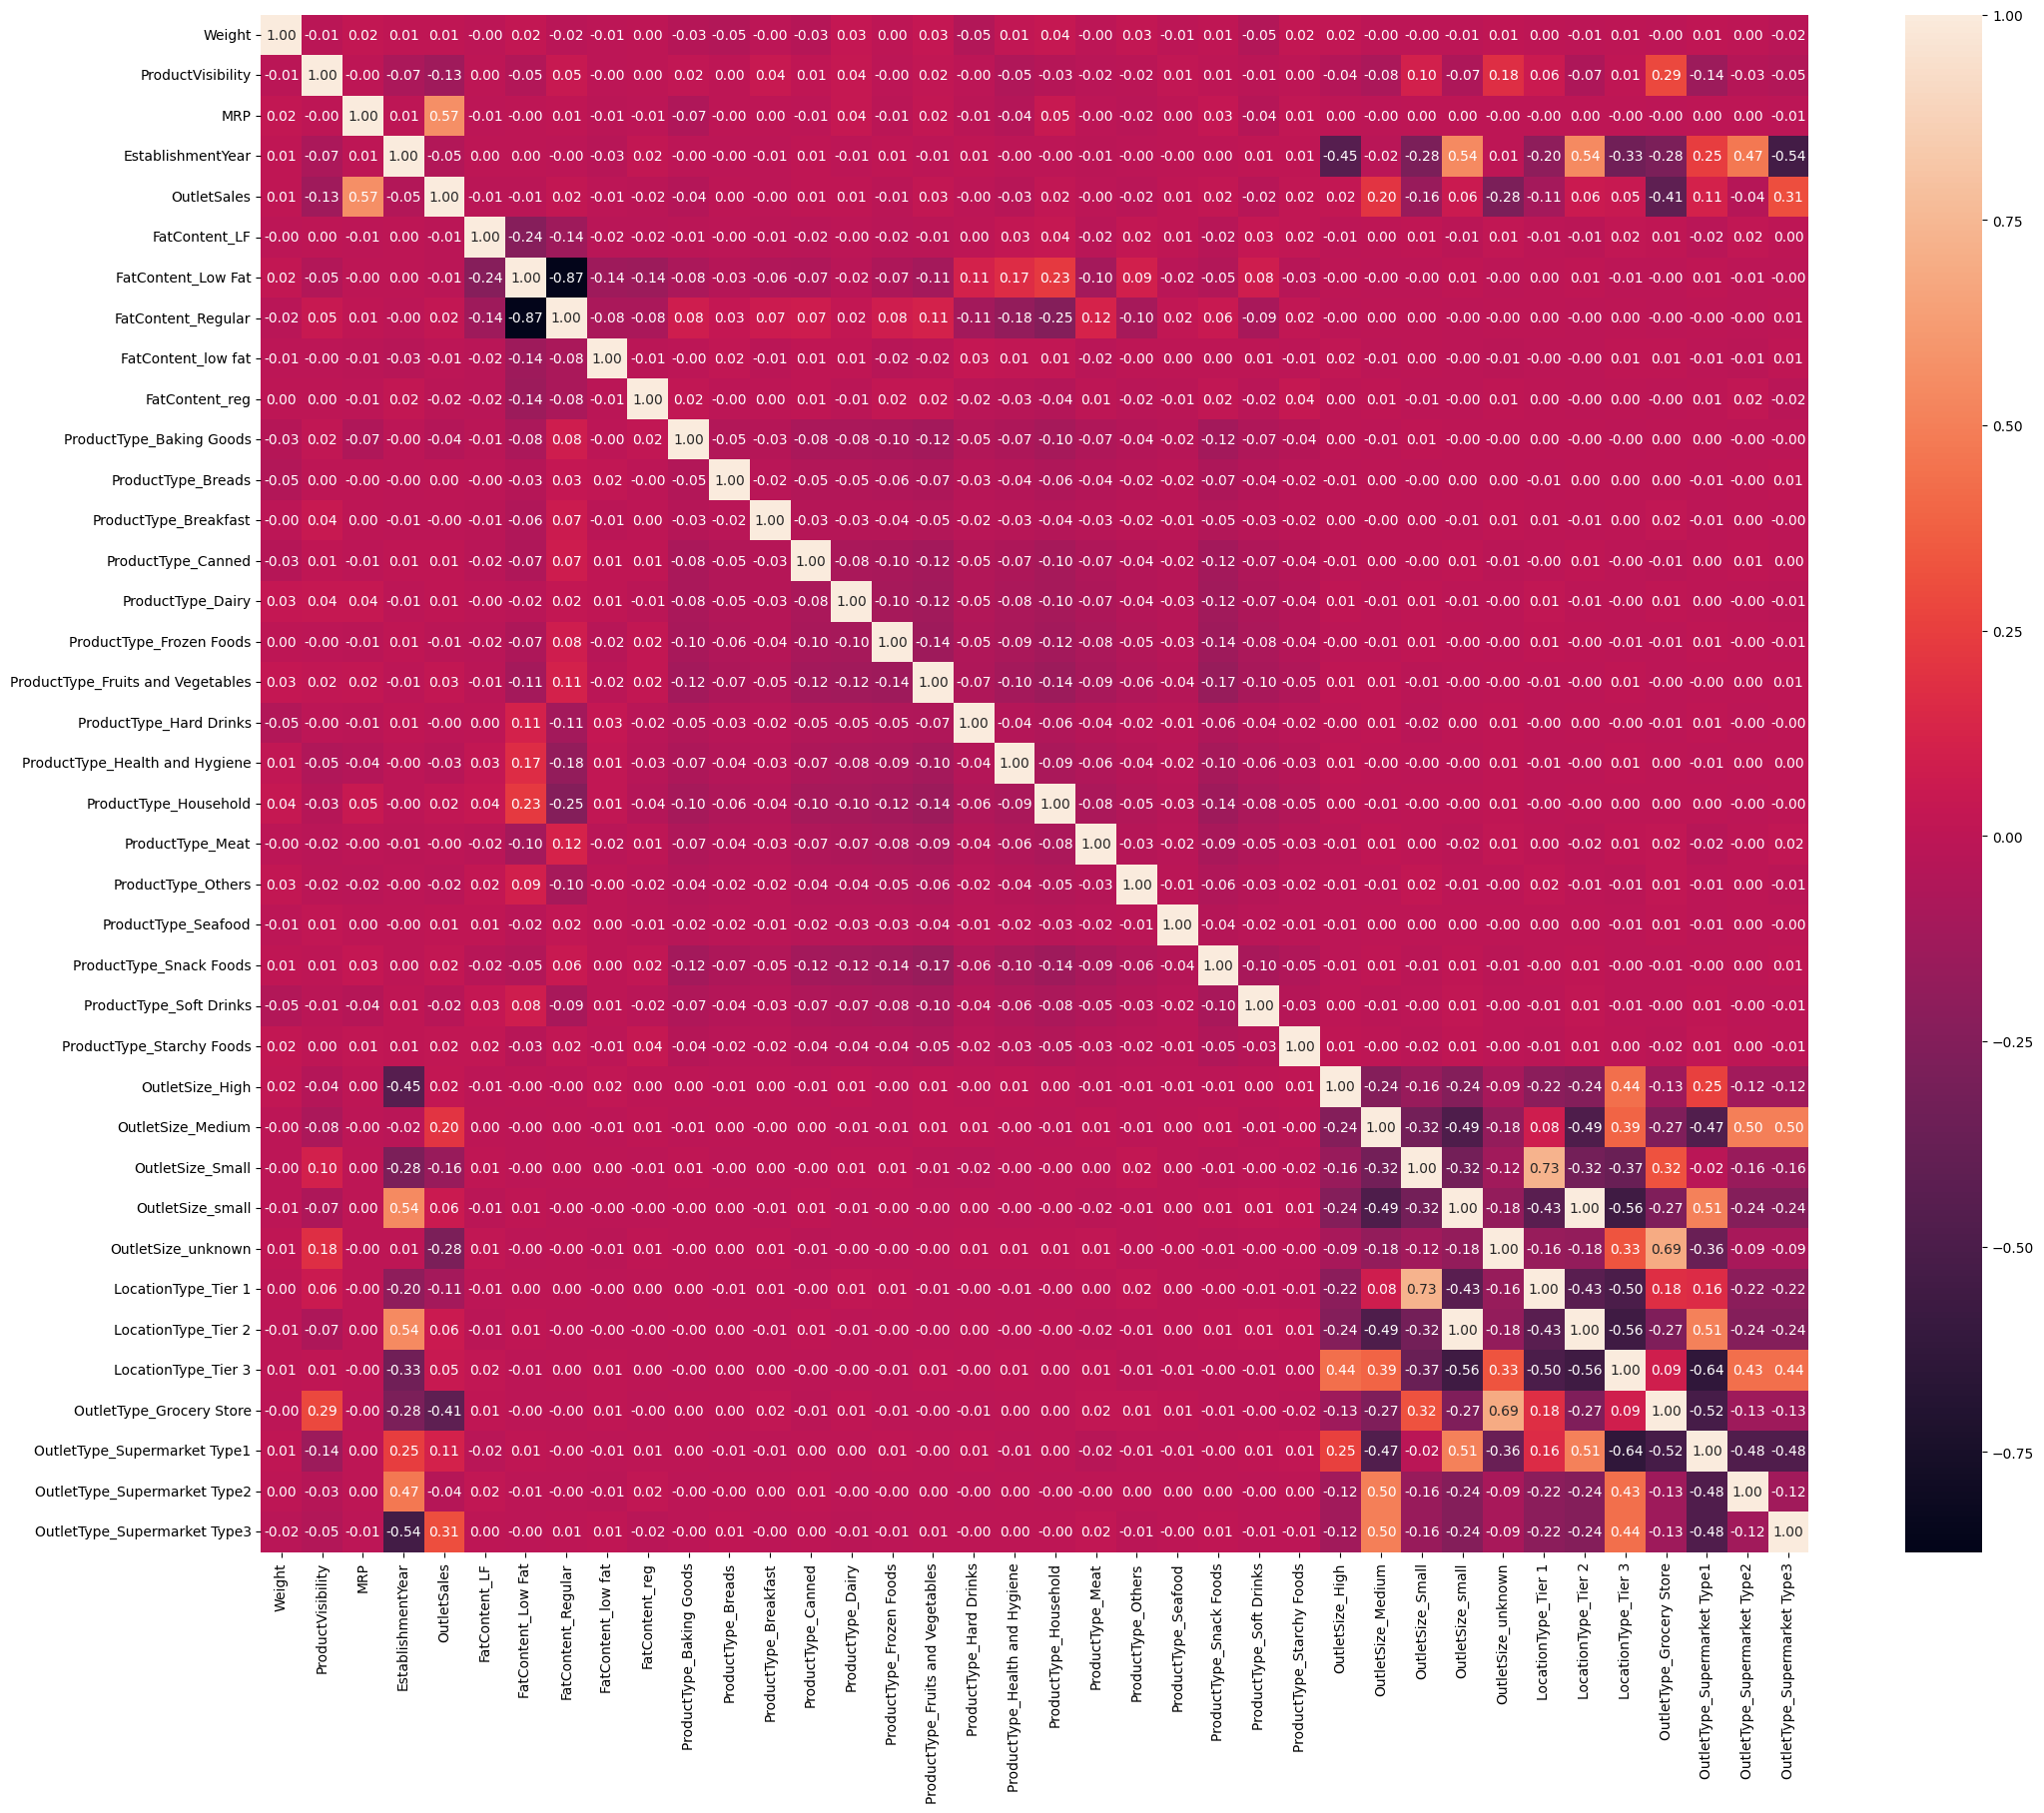

In [63]:
train_corr = train.corr()
plt.figure(figsize=(25,20))
sns.heatmap(train_corr,annot=True,fmt='.2f')
plt.show()

In [64]:
pd.DataFrame(train.corr()['OutletSales'])

,OutletSales
Weight,0.009693
ProductVisibility,-0.128625
MRP,0.567574
EstablishmentYear,-0.049135
OutletSales,1.000000
FatContent_LF,-0.012389
FatContent_Low Fat,-0.011993
FatContent_Regular,0.022618
FatContent_low fat,-0.006326
FatContent_reg,-0.015148


# Model building

In [65]:
train.head()

,Weight,ProductVisibility,MRP,EstablishmentYear,OutletSales,FatContent_LF,FatContent_Low Fat,FatContent_Regular,FatContent_low fat,FatContent_reg,...,OutletSize_Small,OutletSize_small,OutletSize_unknown,LocationType_Tier 1,LocationType_Tier 2,LocationType_Tier 3,OutletType_Grocery Store,OutletType_Supermarket Type1,OutletType_Supermarket Type2,OutletType_Supermarket Type3
0,-0.831187,-0.970732,1.747454,0.139541,3735.1380,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,-1.630810,-0.908111,-1.489023,1.334103,443.4228,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,1.108727,-0.956917,0.010040,0.139541,2097.2700,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1.510904,-1.281758,0.660050,0.020085,732.3800,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
4,-0.918719,-1.281758,-1.399220,-1.293934,994.7052,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [66]:
# splitting train data into feature and labels
X = train.drop(columns=['OutletSales'])
y = train['OutletSales']

In [67]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [68]:
print('Shapes:')
print('X_train',X_train.shape)
print('y_train',y_train.shape)
print('X_test ',X_test.shape)
print('y_test ',y_test.shape)

Shapes:
X_train (6818, 37)
y_train (6818,)
X_test  (1705, 37)
y_test  (1705,)


In [69]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6818 entries, 549 to 7270
Data columns (total 37 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Weight                             6818 non-null   float64
 1   ProductVisibility                  6818 non-null   float64
 2   MRP                                6818 non-null   float64
 3   EstablishmentYear                  6818 non-null   float64
 4   FatContent_LF                      6818 non-null   float64
 5   FatContent_Low Fat                 6818 non-null   float64
 6   FatContent_Regular                 6818 non-null   float64
 7   FatContent_low fat                 6818 non-null   float64
 8   FatContent_reg                     6818 non-null   float64
 9   ProductType_Baking Goods           6818 non-null   float64
 10  ProductType_Breads                 6818 non-null   float64
 11  ProductType_Breakfast              6818 non-null   float64


In [70]:
model = Sequential()

model.add(Dense(72,activation='relu',input_dim=37))
model.add(Dense(36,activation='relu'))
model.add(Dense(36,activation='relu'))

model.add(Dense(1,activation='linear'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-07-26 07:59:51.728652: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [71]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 72)             │         2,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 36)             │         2,628 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 36)             │         1,332 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            37 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,733 (26.30 KB)

 Trainable params: 6,733 (26.30 KB)

 Non-trainable params: 0 (0.00 B)

In [72]:
callback = EarlyStopping(
    monitor='val_loss',
    min_delta= 0.00001,
    patience= 10,
    verbose= 1,
    mode= 'auto',
    baseline= None,
    restore_best_weights= True
)

In [73]:
adam = Adam(learning_rate=0.0005)

In [74]:
model.compile(loss='mean_squared_error',optimizer=adam,metrics=["mae"])
history = model.fit(X_train,y_train,epochs= 300,validation_split=0.2,callbacks=callback)

Epoch 1/300
171/171 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 7637250.5000 - mae: 2164.3782 - val_loss: 7389938.5000 - val_mae: 2113.3440
Epoch 2/300
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4423106.0000 - mae: 1503.8387 - val_loss: 2109293.7500 - val_mae: 1103.3875
Epoch 3/300
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1837119.5000 - mae: 1045.7004 - val_loss: 1665970.1250 - val_mae: 989.8357
Epoch 4/300
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1531551.6250 - mae: 938.5218 - val_loss: 1472625.0000 - val_mae: 905.0552
Epoch 5/300
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1382623.0000 - mae: 871.3356 - val_loss: 1392905.1250 - val_mae: 852.3254
Epoch 6/300
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1315486.5000 - mae: 837.1172 - val_loss: 1346735.5000 - val_mae: 837.7198
Epoch 7/300
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1280284.5000 - mae: 819.0209 - val_loss: 1327236.2500 - val_mae: 829.2655
Epoch 8/300
171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/st

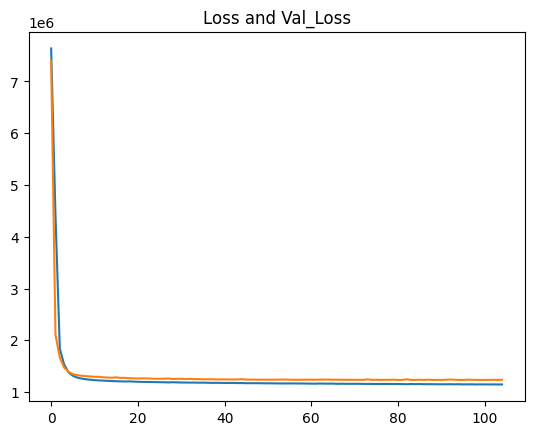

In [75]:
plt.title('Loss and Val_Loss')
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()

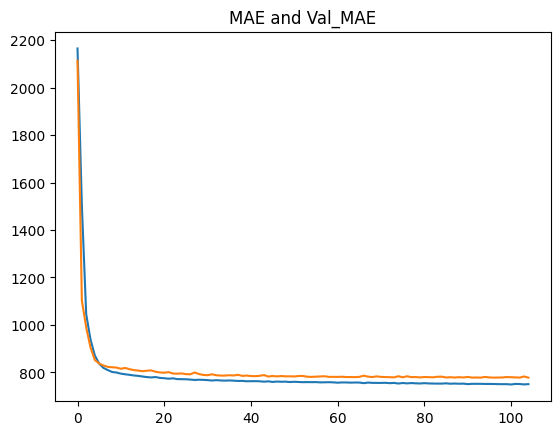

In [76]:
plt.title('MAE and Val_MAE')
plt.plot(history.history['mae'])
plt.plot(history.history['val_mae'])
plt.show()

In [77]:
y_pred = model.predict(X_test)

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [78]:
score= r2_score(y_test,y_pred)
print(score)

0.6166258126025788


In [79]:
train.columns

Index(['Weight', 'ProductVisibility', 'MRP', 'EstablishmentYear',
       'OutletSales', 'FatContent_LF', 'FatContent_Low Fat',
       'FatContent_Regular', 'FatContent_low fat', 'FatContent_reg',
       'ProductType_Baking Goods', 'ProductType_Breads',
       'ProductType_Breakfast', 'ProductType_Canned', 'ProductType_Dairy',
       'ProductType_Frozen Foods', 'ProductType_Fruits and Vegetables',
       'ProductType_Hard Drinks', 'ProductType_Health and Hygiene',
       'ProductType_Household', 'ProductType_Meat', 'ProductType_Others',
       'ProductType_Seafood', 'ProductType_Snack Foods',
       'ProductType_Soft Drinks', 'ProductType_Starchy Foods',
       'OutletSize_High', 'OutletSize_Medium', 'OutletSize_Small',
       'OutletSize_small', 'OutletSize_unknown', 'LocationType_Tier 1',
       'LocationType_Tier 2', 'LocationType_Tier 3',
       'OutletType_Grocery Store', 'OutletType_Supermarket Type1',
       'OutletType_Supermarket Type2', 'OutletType_Supermarket Type3'],
      d

## Hyper parameter Tuning

i will not go with the hyper parameter tunning i will go with my model because it has mae(779) much less then tuned models mae(838) 

# Training

In [80]:
# splitting data into X_train ,y_train
X_train = train.drop(columns=['OutletSales'])
y_train = train['OutletSales']

In [81]:
model = Sequential()

model.add(Dense(72,activation='relu',input_dim=37))
model.add(Dense(36,activation='relu'))
model.add(Dense(36,activation='relu'))

model.add(Dense(1,activation='linear'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [82]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 72)             │         2,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 36)             │         2,628 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 36)             │         1,332 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            37 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,733 (26.30 KB)

 Trainable params: 6,733 (26.30 KB)

 Non-trainable params: 0 (0.00 B)

In [83]:
callback = EarlyStopping(
    monitor='val_loss',
    min_delta= 0.00001,
    patience= 10,
    verbose= 1,
    mode= 'auto',
    baseline= None,
    restore_best_weights= True
)

In [84]:
adam = Adam(learning_rate=0.0005)

In [85]:
model.compile(loss='mean_squared_error',optimizer=adam,metrics=["mae"])
history = model.fit(X_train,y_train,epochs= 300,callbacks=callback)

Epoch 1/300
267/267 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 7102009.0000 - mae: 2060.1157
Epoch 2/300
 68/267 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3960849.0588 - mae: 1397.1248

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,mae
  current = self.get_monitor_value(logs)


267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2243001.0000 - mae: 1095.1559
Epoch 3/300
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1478555.1250 - mae: 914.8534
Epoch 4/300
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1332098.2500 - mae: 848.2018
Epoch 5/300
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1276816.3750 - mae: 818.2587
Epoch 6/300
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1248948.7500 - mae: 804.9901
Epoch 7/300
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1231747.6250 - mae: 797.6832
Epoch 8/300
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1220548.8750 - mae: 790.1415
Epoch 9/300
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1212385.2500 - mae: 787.4276
Epoch 10/300
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1205566.2500 - mae: 783.1188
Epoch 11/300
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1199494.3750 - mae: 780.5612
Epoch 12/300
267/267 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1194812.3750 - mae: 777.6804
Epoch 13/300
267/2

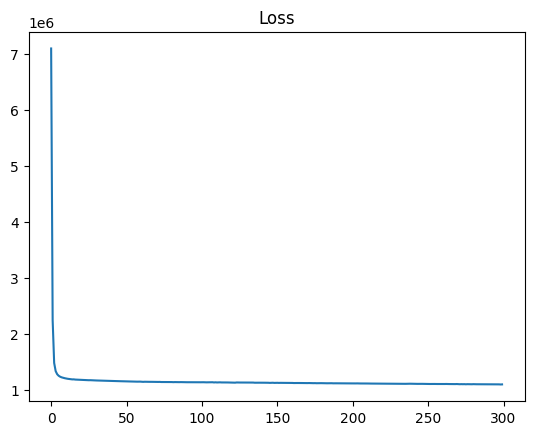

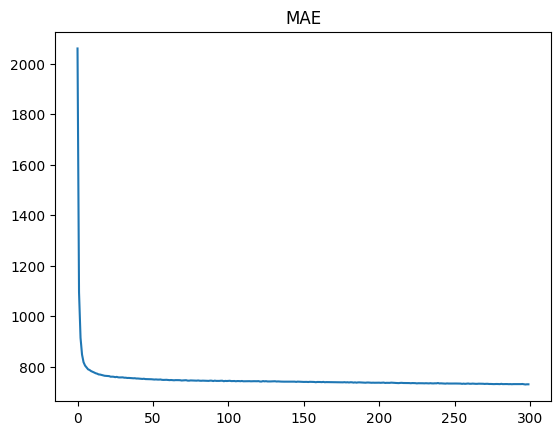

In [86]:
plt.title('Loss')
plt.plot(history.history['loss'])
plt.show()

plt.title('MAE')
plt.plot(history.history['mae'])
plt.show()

# Testing

In [87]:
y_pred = model.predict(test)

178/178 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [88]:
y_pred

array([[1955.7925],
       [1200.6436],
       [ 641.3968],
       ...,
       [1733.9032],
       [4011.4128],
       [1243.0353]], dtype=float32)